# EDA: Encontrar Patrones — Data Detective
### Live coding del profesor

Este notebook sigue el mismo orden que las slides. Cada celda de código
tiene las instrucciones **comentadas**: se van descomentando en vivo
durante la clase, línea por línea.

**Dataset:** `data/rendimiento_estudiantes.csv`
(estudiantes de MAC/Actuaría/Física/CC, con notas, asistencia, sueño, etc.)


In [65]:
print("SETUP: imports y carga de datos")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opcional: mejor estética
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../data/rendimiento_estudiantes.csv')

SETUP: imports y carga de datos


## Bloque 2 — Anatomía del dataset
**Preguntas de detective:**
- ¿Qué observamos?
- ¿Qué columnas existen?
- ¿Qué representa cada fila?


In [90]:
print("Primer contacto con el dataset")

df.head()

Primer contacto con el dataset


,id_estudiante,edad,carrera,ciudad,semestre,horas_estudio,asistencia,horas_sueno,salario,promedio
0,1,18,Física,CDMX,7,13.4,70.9,7.4,3285.0,8.40
1,2,24,Ciencias de la Computación,Naucalpan,5,3.1,78.8,7.4,5227.0,8.76
2,3,23,Actuaría,Naucalpan,6,11.7,100.0,7.0,5518.0,10.00
3,4,21,Física,Naucalpan,8,11.0,92.7,7.2,7805.0,9.75
4,5,21,MAC,Naucalpan,9,7.6,76.6,6.9,4135.0,8.53


In [114]:
print("Tamaño del dataset (n observaciones, p variables)")

df.shape
# # ¿1000 filas significa 1000 personas? -> aqui son 220 estudiantes, 1 fila = 1 estudiante

Tamaño del dataset (n observaciones, p variables)


(220, 10)

In [159]:
print("Conocer las columnas")

df.columns
df.info()

Conocer las columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_estudiante  220 non-null    int64  
 1   edad           220 non-null    int64  
 2   carrera        220 non-null    object 
 3   ciudad         212 non-null    object 
 4   semestre       220 non-null    int64  
 5   horas_estudio  220 non-null    float64
 6   asistencia     220 non-null    float64
 7   horas_sueno    220 non-null    float64
 8   salario        195 non-null    float64
 9   promedio       220 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 17.3+ KB


In [181]:
print("Valores faltantes")

df.isnull().sum()
# # Pregunta: ¿por que podrian faltar esos datos? (ciudad, salario)

Valores faltantes


id_estudiante     0
edad              0
carrera           0
ciudad            8
semestre          0
horas_estudio     0
asistencia        0
horas_sueno       0
salario          25
promedio          0
dtype: int64

In [202]:
print("Duplicados (bonus, no esta en las slides pero siempre se revisa)")

df.duplicated().sum()

Duplicados (bonus, no esta en las slides pero siempre se revisa)


np.int64(0)

## Bloque 3 — Estadística descriptiva
Tres preguntas: ¿dónde están los datos? ¿qué tan dispersos? ¿cómo se distribuyen?


In [222]:
print("Media, mediana y moda manuales (para conectarlo con la formula)")

media = df['promedio'].mean()
mediana = df['promedio'].median()
moda = df['promedio'].mode()[0]
print(media, mediana, moda)

Media, mediana y moda manuales (para conectarlo con la formula)
8.74840909090909 8.77 10.0


In [241]:
print("Dispersion: rango, varianza, desviacion estandar, IQR")

rango = df['promedio'].max() - df['promedio'].min()
varianza = df['promedio'].var()
desv_std = df['promedio'].std()
iqr = df['promedio'].quantile(0.75) - df['promedio'].quantile(0.25)
print(rango, varianza, desv_std, iqr)

Dispersion: rango, varianza, desviacion estandar, IQR
5.2 0.6163403798256537 0.7850734868951146 1.1149999999999984


In [259]:
print("Resumen estadistico completo con pandas")

df.describe()
# # Bonus: incluir columnas categoricas tambien
# df.describe(include='all')

Resumen estadistico completo con pandas


,id_estudiante,edad,semestre,horas_estudio,asistencia,horas_sueno,salario,promedio
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,195.000000,220.000000
mean,110.500000,21.595455,4.963636,10.205000,84.054091,6.395909,4545.292308,8.748409
std,63.652704,2.213487,2.666988,4.725808,11.315437,1.325421,2372.679190,0.785073
min,1.000000,18.000000,1.000000,0.000000,49.400000,3.200000,0.000000,4.800000
25%,55.750000,20.000000,2.000000,7.200000,76.575000,5.375000,3288.000000,8.210000
50%,110.500000,21.500000,5.000000,9.900000,85.550000,6.400000,4460.000000,8.770000
75%,165.250000,24.000000,7.000000,12.525000,92.450000,7.300000,5642.000000,9.325000
max,220.000000,25.000000,9.000000,45.000000,100.000000,9.800000,25000.000000,10.000000


## Bloque 4 — Variables y distribuciones
Histograma, sesgo (media vs mediana) y boxplot.


Histograma de una variable numerica


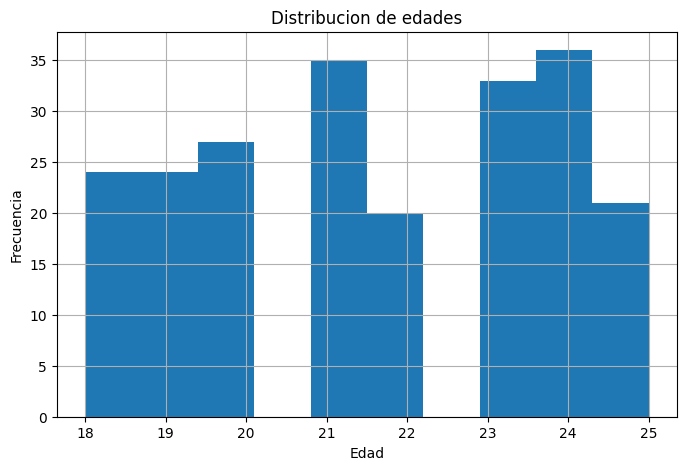

In [276]:
print("Histograma de una variable numerica")

df['edad'].hist(bins=10)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribucion de edades')
plt.show()

Histograma de horas de estudio (ver cola / outliers)


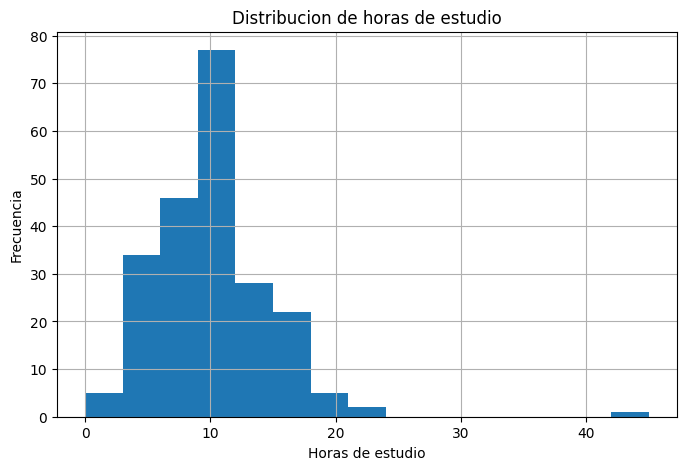

In [292]:
print("Histograma de horas de estudio (ver cola / outliers)")

df['horas_estudio'].hist(bins=15)
plt.xlabel('Horas de estudio')
plt.ylabel('Frecuencia')
plt.title('Distribucion de horas de estudio')
plt.show()

In [307]:
print("Sesgo: comparar media vs mediana")

media_he = df['horas_estudio'].mean()
mediana_he = df['horas_estudio'].median()
print('media:', media_he, ' mediana:', mediana_he)
# # Si media > mediana -> sesgo positivo (cola a la derecha)

Sesgo: comparar media vs mediana
media: 10.205  mediana: 9.9


Boxplot de promedio


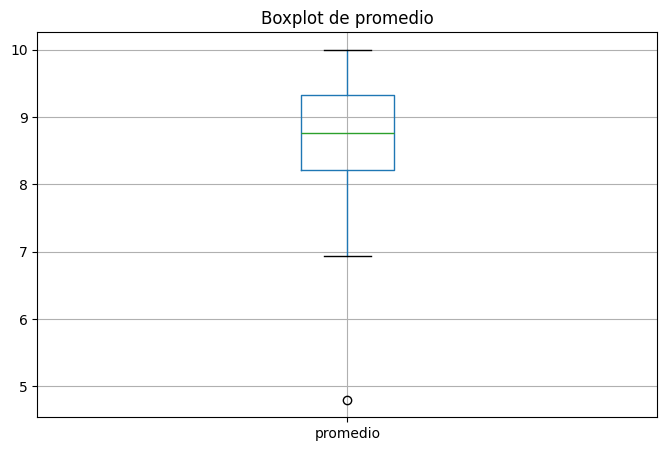

In [321]:
print("Boxplot de promedio")

df.boxplot(column='promedio')
plt.title('Boxplot de promedio')
plt.show()

## Bloque 5 — Outliers
Método del rango intercuartílico (IQR).
Recordatorio: un outlier NO es automáticamente un error.


In [334]:
print("Detectar outliers en 'promedio' con el metodo IQR")

Q1 = df['promedio'].quantile(0.25)
Q3 = df['promedio'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR
outliers = df[(df['promedio'] < limite_inf) | (df['promedio'] > limite_sup)]
print(outliers)

Detectar outliers en 'promedio' con el metodo IQR
     id_estudiante  edad carrera     ciudad  semestre  horas_estudio  \
218            219    21     MAC  Querétaro         1            3.7   

     asistencia  horas_sueno  salario  promedio  
218        87.4          6.6   5500.0       4.8  


In [335]:
print("Repetir para 'horas_estudio' y 'salario'")

# for col in ['horas_estudio', 'salario']:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
#     print(col, '->', df[(df[col] < lo) | (df[col] > hi)][['id_estudiante', col]])

Repetir para 'horas_estudio' y 'salario'


## Bloque 6 — Relaciones entre variables
Covarianza, correlación de Pearson y matriz de correlación.
Recordar: **correlación no implica causalidad**.


In [346]:
print("Covarianza entre horas de estudio y promedio")

df[['horas_estudio', 'promedio']].cov()

Covarianza entre horas de estudio y promedio


,horas_estudio,promedio
horas_estudio,22.333263,2.224154
promedio,2.224154,0.616340


In [356]:
print("Correlacion de Pearson")

r = df['horas_estudio'].corr(df['promedio'])
print('correlacion horas_estudio vs promedio:', r)

Correlacion de Pearson
correlacion horas_estudio vs promedio: 0.5994852184716308


In [365]:
print("Matriz de correlacion completa")

corr = df.corr(numeric_only=True)
print(corr)

Matriz de correlacion completa
               id_estudiante      edad  semestre  horas_estudio  asistencia  \
id_estudiante       1.000000 -0.050509 -0.098312       0.016181   -0.032283   
edad               -0.050509  1.000000  0.018381       0.067636    0.134875   
semestre           -0.098312  0.018381  1.000000       0.092544    0.020583   
horas_estudio       0.016181  0.067636  0.092544       1.000000    0.005166   
asistencia         -0.032283  0.134875  0.020583       0.005166    1.000000   
horas_sueno         0.026096  0.048927 -0.009472      -0.076724   -0.042926   
salario            -0.118472 -0.019331 -0.131022      -0.206892   -0.010013   
promedio           -0.015648  0.095564  0.038966       0.599485    0.174341   

               horas_sueno   salario  promedio  
id_estudiante     0.026096 -0.118472 -0.015648  
edad              0.048927 -0.019331  0.095564  
semestre         -0.009472 -0.131022  0.038966  
horas_estudio    -0.076724 -0.206892  0.599485  
asistencia  

## Bloque 7 — Visualización
Cada gráfica debe responder una pregunta concreta.


Scatterplot: horas de estudio vs promedio


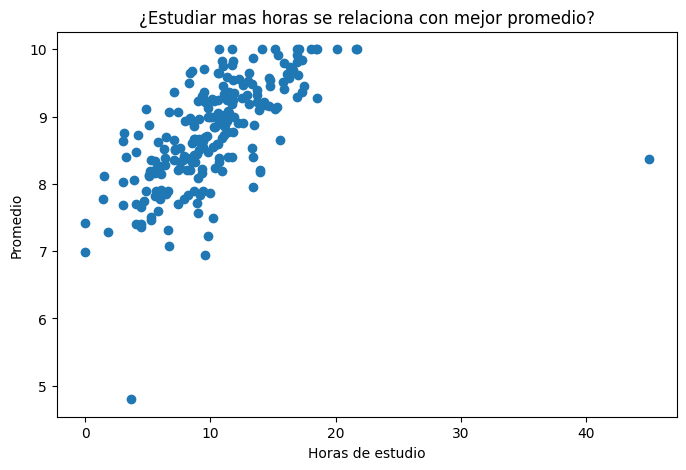

In [373]:
print("Scatterplot: horas de estudio vs promedio")

plt.scatter(df['horas_estudio'], df['promedio'])
plt.xlabel('Horas de estudio')
plt.ylabel('Promedio')
plt.title('¿Estudiar mas horas se relaciona con mejor promedio?')
plt.show()

Heatmap de correlaciones (con matplotlib puro, sin seaborn)


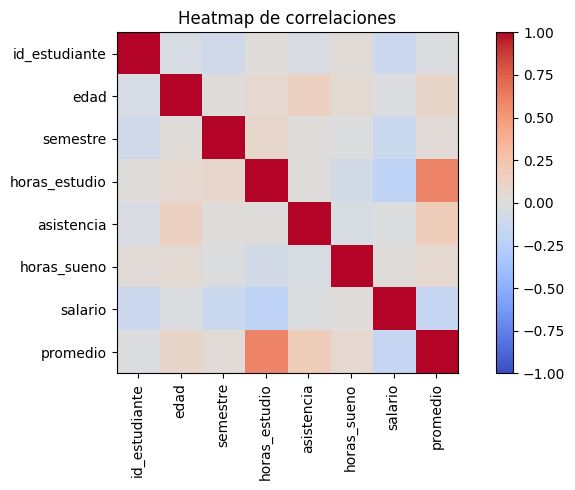

In [380]:
print("Heatmap de correlaciones (con matplotlib puro, sin seaborn)")

corr = df.corr(numeric_only=True)
fig, ax = plt.subplots()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im)
plt.title('Heatmap de correlaciones')
plt.tight_layout()
plt.show()

Boxplot comparando promedio por carrera (comparar grupos)


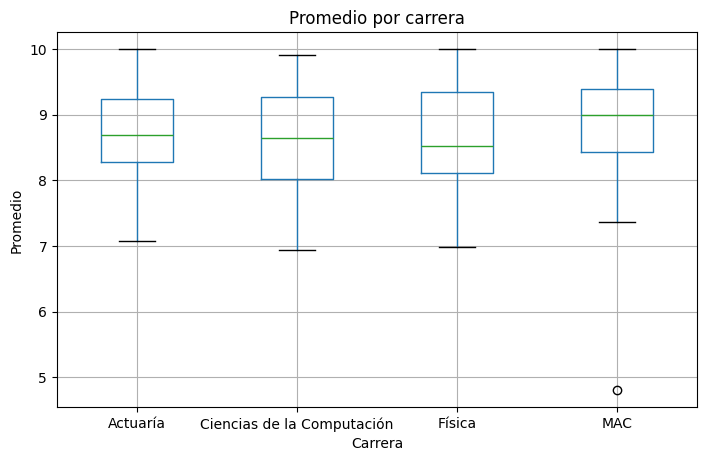

In [386]:
print("Boxplot comparando promedio por carrera (comparar grupos)")

df.boxplot(column='promedio', by='carrera')
plt.title('Promedio por carrera')
plt.suptitle('')
plt.xlabel('Carrera')
plt.ylabel('Promedio')
plt.show()

## Bloque 8 — Caso: El misterio del rendimiento

**Misión:** descubrir qué factores parecen estar relacionados con el
rendimiento académico (promedio).

### Pista 1: Conocer la escena


In [391]:
print("Pista 1: conocer la escena")

df.head()
df.shape
df.info()
df.describe()

Pista 1: conocer la escena
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_estudiante  220 non-null    int64  
 1   edad           220 non-null    int64  
 2   carrera        220 non-null    object 
 3   ciudad         212 non-null    object 
 4   semestre       220 non-null    int64  
 5   horas_estudio  220 non-null    float64
 6   asistencia     220 non-null    float64
 7   horas_sueno    220 non-null    float64
 8   salario        195 non-null    float64
 9   promedio       220 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 17.3+ KB


,id_estudiante,edad,semestre,horas_estudio,asistencia,horas_sueno,salario,promedio
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,195.000000,220.000000
mean,110.500000,21.595455,4.963636,10.205000,84.054091,6.395909,4545.292308,8.748409
std,63.652704,2.213487,2.666988,4.725808,11.315437,1.325421,2372.679190,0.785073
min,1.000000,18.000000,1.000000,0.000000,49.400000,3.200000,0.000000,4.800000
25%,55.750000,20.000000,2.000000,7.200000,76.575000,5.375000,3288.000000,8.210000
50%,110.500000,21.500000,5.000000,9.900000,85.550000,6.400000,4460.000000,8.770000
75%,165.250000,24.000000,7.000000,12.525000,92.450000,7.300000,5642.000000,9.325000
max,220.000000,25.000000,9.000000,45.000000,100.000000,9.800000,25000.000000,10.000000


### Pista 2: Distribuciones (edad, horas_estudio, promedio, horas_sueno)

Pista 2: distribuciones


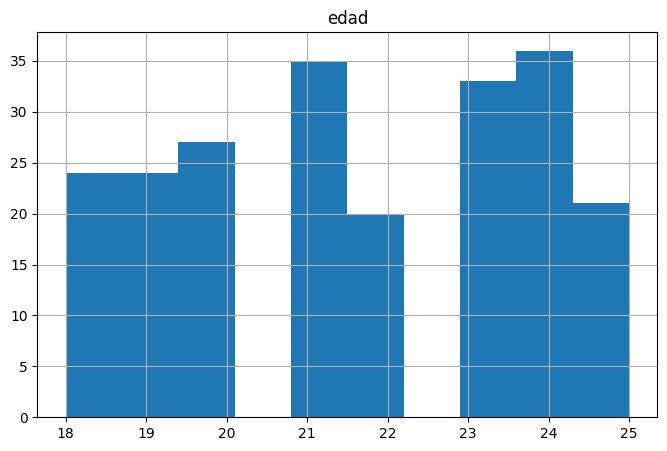

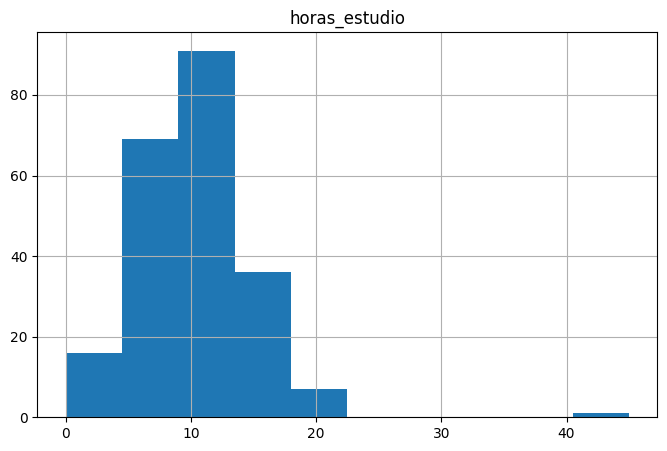

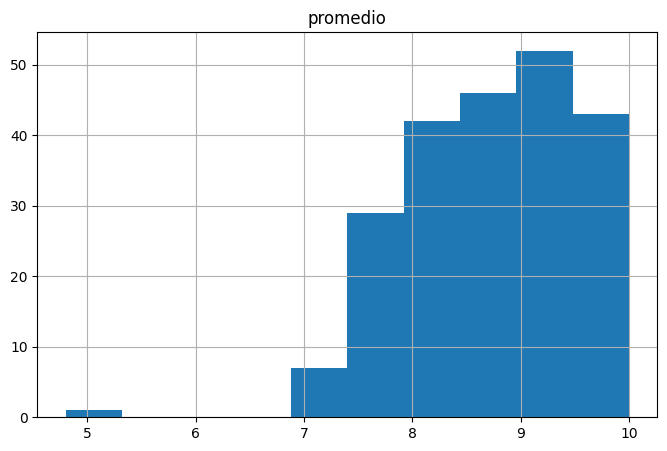

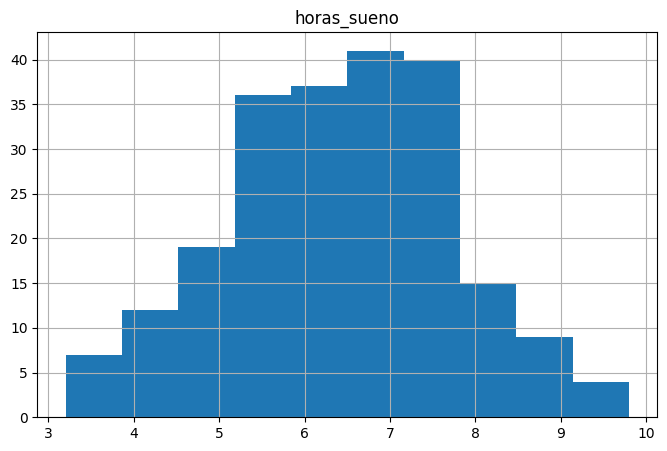

In [398]:
print("Pista 2: distribuciones")

for col in ['edad', 'horas_estudio', 'promedio', 'horas_sueno']:
     df[col].hist(bins=10)
     plt.title(col)
     plt.show()

### Pista 3: Relaciones (horas_estudio, asistencia, horas_sueno) vs promedio

In [401]:
print("Pista 3: relaciones")

for col in ['horas_estudio', 'asistencia', 'horas_sueno']:
     r = df[col].corr(df['promedio'])
     print(col, '-> correlacion con promedio:', round(r, 3))

Pista 3: relaciones
horas_estudio -> correlacion con promedio: 0.599
asistencia -> correlacion con promedio: 0.174
horas_sueno -> correlacion con promedio: 0.057


### Pista 4: El sospechoso (casos extremos)

In [403]:
print("Pista 4: casos extremos")

print('Menor promedio:')
print(df.loc[df['promedio'].idxmin()])
print()
print('Mayor promedio:')
print(df.loc[df['promedio'].idxmax()])
print()
print('Mas horas de estudio:')
print(df.loc[df['horas_estudio'].idxmax()])

Pista 4: casos extremos
Menor promedio:
id_estudiante          219
edad                    21
carrera                MAC
ciudad           Querétaro
semestre                 1
horas_estudio          3.7
asistencia            87.4
horas_sueno            6.6
salario             5500.0
promedio               4.8
Name: 218, dtype: object

Mayor promedio:
id_estudiante            3
edad                    23
carrera           Actuaría
ciudad           Naucalpan
semestre                 6
horas_estudio         11.7
asistencia           100.0
horas_sueno            7.0
salario             5518.0
promedio              10.0
Name: 2, dtype: object

Mas horas de estudio:
id_estudiante           46
edad                    25
carrera           Actuaría
ciudad           Querétaro
semestre                 8
horas_estudio         45.0
asistencia            95.1
horas_sueno            4.4
salario             3587.0
promedio              8.37
Name: 45, dtype: object


### Pista 5: La hipótesis

Ejemplo de hipótesis a formular con el grupo:

> "Los estudiantes que estudian más horas tienden a obtener mejores promedios."

Hipótesis → Evidencia → Conclusión.


## Checklist final (antes de "modelar")
- [ ] ¿Conozco mi dataset?
- [ ] ¿Sé qué representa cada variable?
- [ ] ¿Revisé valores faltantes?
- [ ] ¿Revisé duplicados?
- [ ] ¿Encontré valores extraños?
- [ ] ¿Conozco las distribuciones?
- [ ] ¿Busqué relaciones?
- [ ] ¿Visualicé los patrones?
- [ ] ¿Tengo hipótesis?
- [ ] ¿Puedo defender mis conclusiones?
